<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/K_Means_clusstering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
i0mport pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sn



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Edunet/Enviromental factor')

print(df.head())
print(df.isnull().sum())
df.fillna(df.mean(), inplace=True)
print(df.isnull().sum())



   temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    22.490802  52.418449   19.599966        337.165056        369.020837   
1    34.014286  49.974726    8.690240        256.681604        185.335998   
2    29.639879  40.569235   11.932794        484.024336        213.723302   
3    26.973170  66.436000   18.265613        148.540303        262.604015   
4    18.120373  58.597450   14.641787        314.535387        283.288001   

   pollution_level  
0        84.723658  
1        49.451704  
2        19.546561  
3        73.664179  
4        41.867814  
temperature         0
humidity            0
wind_speed          0
carbon_emissions    0
solar_irradiance    0
pollution_level     0
dtype: int64
temperature         0
humidity            0
wind_speed          0
carbon_emissions    0
solar_irradiance    0
pollution_level     0
dtype: int64


In [ ]:
print(df.head())

   temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    22.490802  52.418449   19.599966        337.165056        369.020837   
1    34.014286  49.974726    8.690240        256.681604        185.335998   
2    29.639879  40.569235   11.932794        484.024336        213.723302   
3    26.973170  66.436000   18.265613        148.540303        262.604015   
4    18.120373  58.597450   14.641787        314.535387        283.288001   

   pollution_level  
0        84.723658  
1        49.451704  
2        19.546561  
3        73.664179  
4        41.867814  


In [ ]:
df.shape

(10000, 6)

In [ ]:
X = df[['temperature', 'humidity', 'wind_speed', 'carbon_emissions', 'solar_irradiance']]
y = df['pollution_level']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
data_scaled = scaler.fit_transform(df)
#X_train=scaler.fit_transform(X_train)
#X_test=scaler.fit_transform(X_test)

In [ ]:
# defining that how many clusters will be there
k = 4
model=KMeans(n_clusters=k, random_state=42)
df['cluster']=model.fit_predict(data_scaled)

print(df.head())

   temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    22.490802  52.418449   19.599966        337.165056        369.020837   
1    34.014286  49.974726    8.690240        256.681604        185.335998   
2    29.639879  40.569235   11.932794        484.024336        213.723302   
3    26.973170  66.436000   18.265613        148.540303        262.604015   
4    18.120373  58.597450   14.641787        314.535387        283.288001   

   pollution_level  cluster  
0        84.723658        2  
1        49.451704        3  
2        19.546561        3  
3        73.664179        2  
4        41.867814        2  


In [ ]:
#calculate silhouettte score

sil_score=silhouette_score(data_scaled,df['cluster'])
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.1198424886498103


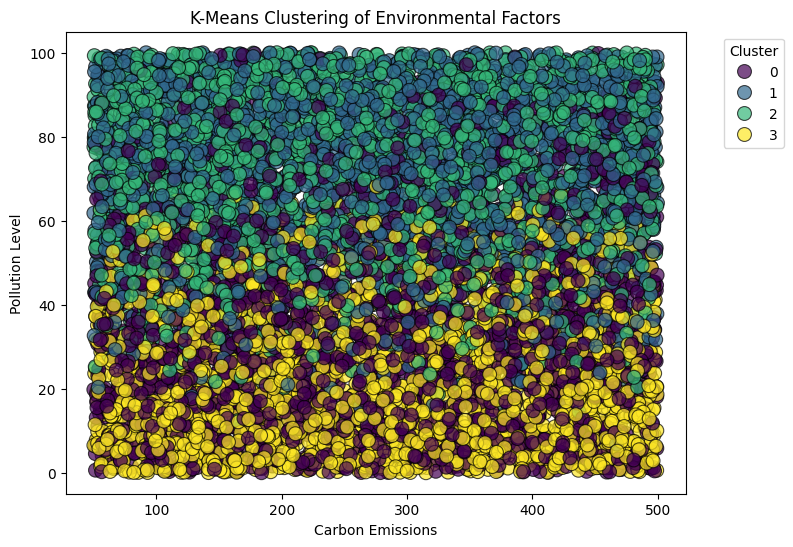

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming `data` already contains the cluster labels (from the KMeans model)
# We'll use two features to plot: 'carbon_emissions' and 'pollution_level'
plt.figure(figsize=(8, 6))
# Create a scatter plot with the cluster labels
sns.scatterplot(x='carbon_emissions', y='pollution_level', hue='cluster',
                data=df, palette='viridis', s=100, alpha=0.7, edgecolor='k')
# Title and labels
plt.title('K-Means Clustering of Environmental Factors')
plt.xlabel('Carbon Emissions')
plt.ylabel('Pollution Level')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# Display the plot
plt.show()


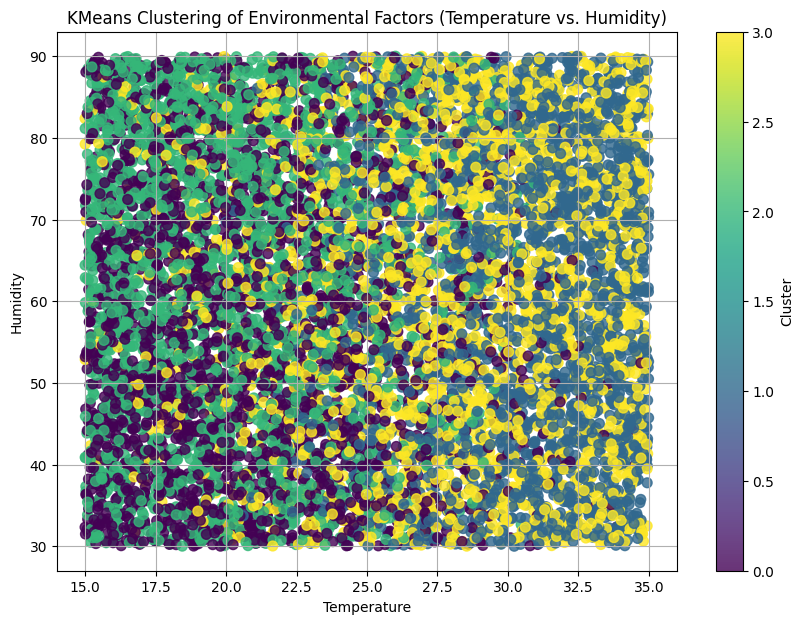

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(df['temperature'], df['humidity'], c=df['cluster'], cmap='viridis', s=50, alpha=0.8)
plt.title('KMeans Clustering of Environmental Factors (Temperature vs. Humidity)')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [ ]:
y_pred=model.predict(X_test)
print(y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


ValueError: X has 5 features, but KMeans is expecting 6 features as input.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R-squared:", r2)
print("Mean Squared Error:", mse)

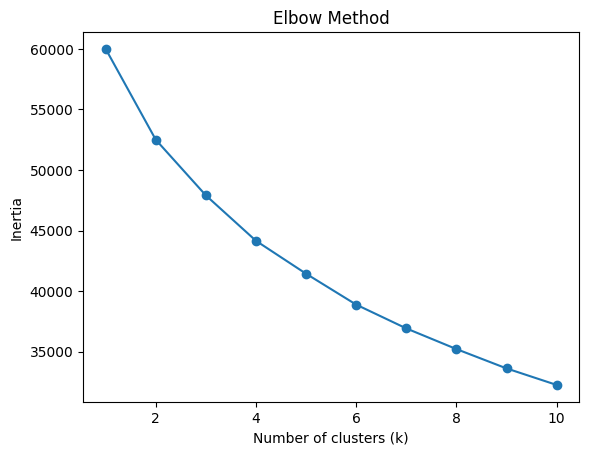

In [ ]:
# Use the Elbow method to find the optimal number of clusters
inertia = []
k_range = range(1, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)


# Plot the inertia values to find the "elbow"
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

#confution matrix

cm_result=sk_confusion_matrix(y_test,y_pred)
sn.heatmap(cm_result,annot=True,fmt='d',cmap='Blues',
           xticklabels=['Unsustainability ','sustainability'],
           yticklabels=['Unsustainability ','sustainability']
           )
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.show()


NameError: name 'y_pred' is not defined

getting report of prcision ,recall, and f1 score, support

In [ ]:
print(classification_report(y_test,y_pred,target_names=['Unsustainability','sustainability']))

NameError: name 'classification_report' is not defined

In [ ]:
#trying difference value for k
k_values = list(range(1, 21)) # Test k from 1 to 20
accuracies = []

for k_val in k_values:
    model = KNeighborsClassifier(n_neighbors=k_val)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

In [ ]:
# Re-initialize and train the DecisionTreeClassifier for plotting
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
from sklearn.tree import plot_tree
plot_tree(dt_model, feature_names=X.columns, class_names=['non adoption', 'adoption'], filled=True, rounded=True)
plt.title('Decision Tree')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

In [ ]:
# Print the k value with the highest accuracy

best_k = k_values[np.argmax(accuracies)]
max_accuracy = np.max(accuracies)

min_accuracy = np.min(accuracies)

print(f"The best 'k' value is {best_k} with an accuracy of {min_accuracy:.4f}")
# print(f"The best 'k' value is {best_k} with an accuracy of {max_accuracy:.4f}")

